# ÁRVORE DE BUSCA E-OU
> Junção de dois tipos de árvores (E-OU) :
- Em um determinado nó, o agente escolhe entre: *Aspirar ou Esquerda ou Direita*
- Em um ambiente não determinístico, a ramificação é apresentada pela escolha do resultado do ambiente. Esses nós são chamados de **E**, por exemplo:
    A ação *Aspirar* no estado 1 leva ao conjunto *{5,7}*, então o agente deve traçar um plano para o estado 5 ==E== para o estado 7


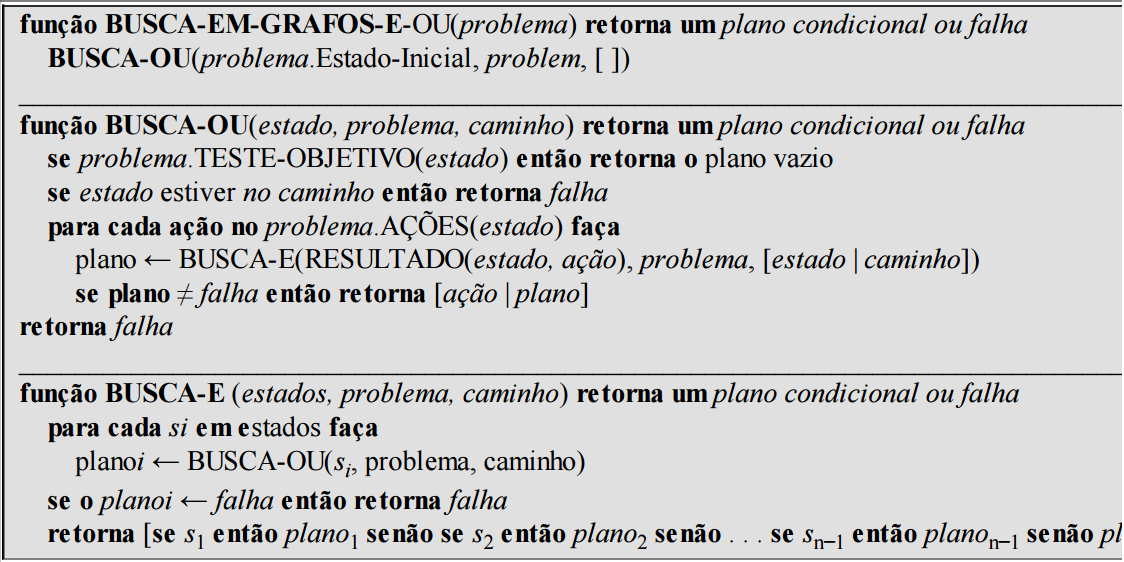

In [1]:
FALHA = None


def busca_em_grafo_e_ou(problema):
    """
    Função principal.
    """
    return busca_ou(problema.estado_inicial, problema, [])


def busca_ou(estado, problema, caminho):
    """
    Nó OU: escolhe uma ação que leve a um plano válido.
    """
    
    # Se atingiu objetivo → plano vazio
    if problema.teste_objetivo(estado):
        return []

    # Verificação de ciclo
    if estado in caminho:
        return FALHA

    # Para cada ação possível
    for acao in problema.acoes(estado):
        
        estados_resultantes = problema.resultado(estado, acao)
        
        plano = busca_e(estados_resultantes, problema, [estado] + caminho)
        
        if plano is not FALHA:
            return (acao, plano)

    return FALHA


def busca_e(estados, problema, caminho):
    """
    Nó E: todos os estados devem ter solução.
    """
    
    plano_total = {}

    for si in estados:
        
        plano_i = busca_ou(si, problema, caminho)
        
        if plano_i is FALHA:
            return FALHA
        
        plano_total[si] = plano_i

    return plano_total

In [2]:
class ExemploProblema:
    
    def __init__(self):
        self.estado_inicial = "A"
        self.objetivo = "D"

    def acoes(self, estado):
        mapa = {
            "A": ["ir"],
            "B": ["ir"],
            "C": ["ir"],
            "D": []
        }
        return mapa.get(estado, [])

    def resultado(self, estado, acao):
        transicoes = {
            ("A", "ir"): ["B", "C"],
            ("B", "ir"): ["D"],
            ("C", "ir"): ["D"]
        }
        return transicoes.get((estado, acao), [])

    def teste_objetivo(self, estado):
        return estado == self.objetivo

In [3]:
problema = ExemploProblema()
plano = busca_em_grafo_e_ou(problema)
print(plano)

('ir', {'B': ('ir', {'D': []}), 'C': ('ir', {'D': []})})
